# Batch Quality Classification - Custom Project (Abdelhafidh Mahouel)

Applies the classification workflow techniques from this module (train/test split,
model training, confusion matrix, precision/recall/F1) to a new problem: predicting
whether a manufacturing batch will pass or fail final spec compliance testing,
based on in-process measurements.

**Dataset:** `data/raw/batch_quality_abdel.csv`

**Target:** `batch_pass` (1 = passed final spec compliance, 0 = failed)


## Section 1. Imports and Configuration

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [20]:
DATASET_NAME = "batch_quality_abdel"

TARGET_COL = "batch_pass"

FEATURE_COLS = [
    "mixing_time_min",
    "process_temp_c",
    "ph_level",
    "viscosity_cp",
    "raw_material_age_days",
    "operator_experience_yrs",
    "humidity_pct",
    "line_speed_units_min",
]

TEST_SIZE = 0.30
RANDOM_STATE = 42
MAX_DEPTH = 4

## Section 2. Load the Data

In [21]:
df = pd.read_csv(f"../data/raw/{DATASET_NAME}.csv")

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded: 300 rows, 10 columns


,batch_id,mixing_time_min,process_temp_c,ph_level,viscosity_cp,raw_material_age_days,operator_experience_yrs,humidity_pct,line_speed_units_min,batch_pass
0,B100000,46.8,75.2,7.13,1258.0,37,4,47.6,76.7,1
1,B100001,38.8,65.4,6.86,1215.0,19,14,35.8,78.5,1
2,B100002,49.5,72.6,7.32,1178.0,10,10,50.7,74.4,1
3,B100003,50.6,69.0,6.84,1438.0,38,6,35.5,75.6,0
4,B100004,33.3,69.8,6.84,1107.0,47,10,40.5,79.6,1


## Section 3. Inspect Data Shape and Structure

In [22]:
print("Column names:")
print(list(df.columns))
print()
df.info()

Column names:
['batch_id', 'mixing_time_min', 'process_temp_c', 'ph_level', 'viscosity_cp', 'raw_material_age_days', 'operator_experience_yrs', 'humidity_pct', 'line_speed_units_min', 'batch_pass']

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   batch_id                 300 non-null    str    
 1   mixing_time_min          300 non-null    float64
 2   process_temp_c           300 non-null    float64
 3   ph_level                 300 non-null    float64
 4   viscosity_cp             300 non-null    float64
 5   raw_material_age_days    300 non-null    int64  
 6   operator_experience_yrs  300 non-null    int64  
 7   humidity_pct             300 non-null    float64
 8   line_speed_units_min     300 non-null    float64
 9   batch_pass               300 non-null    int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 23.6 KB


In [23]:
print("Target class balance:")
df[TARGET_COL].value_counts(normalize=True)

Target class balance:


batch_pass
1    0.62
0    0.38
Name: proportion, dtype: float64

## Section 4. Check Data Quality

In [24]:
print("Missing values by column:")
print(df.isna().sum())
print()
print(f"Duplicate row count: {df.duplicated().sum()}")

Missing values by column:
batch_id                   0
mixing_time_min            0
process_temp_c             0
ph_level                   0
viscosity_cp               0
raw_material_age_days      0
operator_experience_yrs    0
humidity_pct               0
line_speed_units_min       0
batch_pass                 0
dtype: int64

Duplicate row count: 0


## Section 5. Create a Clean View

In [25]:
selected_cols = FEATURE_COLS + [TARGET_COL]

df_selected = df[selected_cols]
df_clean = df_selected.dropna().copy()

print(f"Clean view: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
df_clean.head()

Clean view: 300 rows, 9 columns


,mixing_time_min,process_temp_c,ph_level,viscosity_cp,raw_material_age_days,operator_experience_yrs,humidity_pct,line_speed_units_min,batch_pass
0,46.8,75.2,7.13,1258.0,37,4,47.6,76.7,1
1,38.8,65.4,6.86,1215.0,19,14,35.8,78.5,1
2,49.5,72.6,7.32,1178.0,10,10,50.7,74.4,1
3,50.6,69.0,6.84,1438.0,38,6,35.5,75.6,0
4,33.3,69.8,6.84,1107.0,47,10,40.5,79.6,1


## Section 6. Explore Relationships (EDA)

A quick look at how a couple of features relate to the target before modeling.

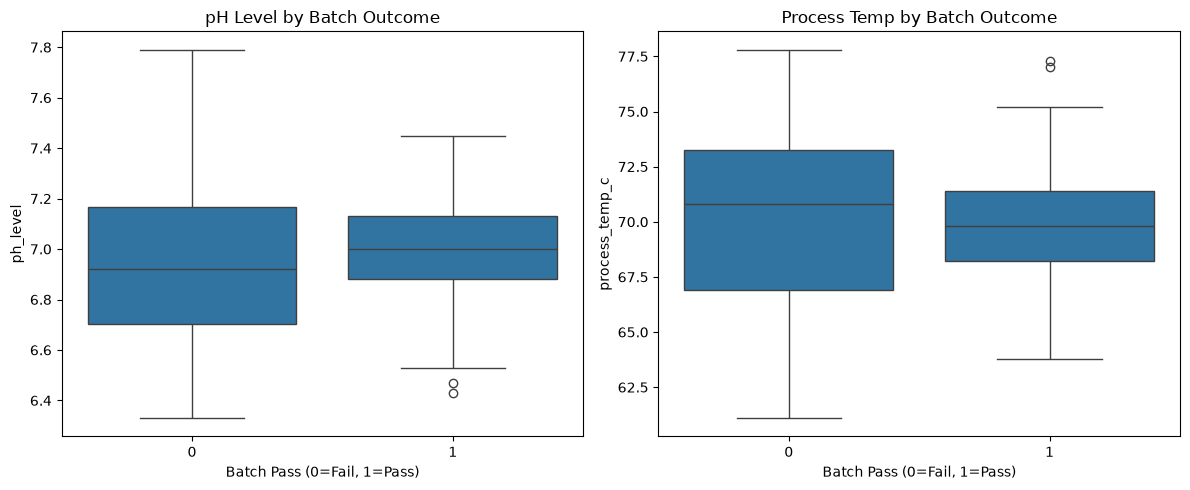

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x=TARGET_COL, y="ph_level", ax=axes[0])
axes[0].set_title("pH Level by Batch Outcome")
axes[0].set_xlabel("Batch Pass (0=Fail, 1=Pass)")

sns.boxplot(data=df_clean, x=TARGET_COL, y="process_temp_c", ax=axes[1])
axes[1].set_title("Process Temp by Batch Outcome")
axes[1].set_xlabel("Batch Pass (0=Fail, 1=Pass)")

plt.tight_layout()
plt.show()

## Section 7. Train Supervised Classification Model

We train a `DecisionTreeClassifier` and hold out 30% of the data for testing.

In [27]:
x = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.644


## Section 8. Evaluate Model Performance

In [28]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=actual, cols=predicted):")
print(cm)

Confusion matrix (rows=actual, cols=predicted):
[[18 16]
 [16 40]]


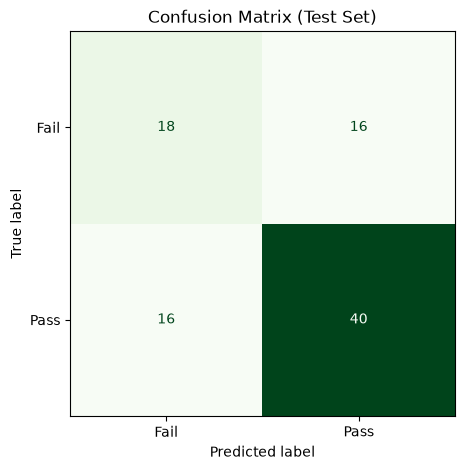

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")
plt.show()

In [30]:
print("Classification report (precision, recall, F1):")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Classification report (precision, recall, F1):
              precision    recall  f1-score   support

        Fail       0.53      0.53      0.53        34
        Pass       0.71      0.71      0.71        56

    accuracy                           0.64        90
   macro avg       0.62      0.62      0.62        90
weighted avg       0.64      0.64      0.64        90



## Section 9. Feature Importance

Which in-process measurements matter most for predicting batch outcome?

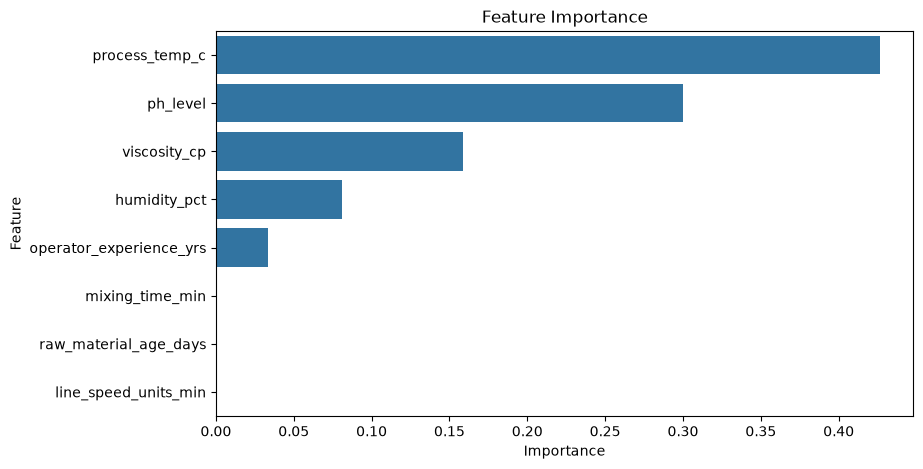

,feature,importance
1,process_temp_c,0.426667
2,ph_level,0.299772
3,viscosity_cp,0.158794
6,humidity_pct,0.081288
5,operator_experience_yrs,0.033478
0,mixing_time_min,0.000000
4,raw_material_age_days,0.000000
7,line_speed_units_min,0.000000


In [31]:
importance_df = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.show()

importance_df

## Section 10. Predict One New Case

In [32]:
new_case = pd.DataFrame(
    [
        {
            "mixing_time_min": 44.5,
            "process_temp_c": 69.8,
            "ph_level": 7.02,
            "viscosity_cp": 1180,
            "raw_material_age_days": 15,
            "operator_experience_yrs": 8,
            "humidity_pct": 46.0,
            "line_speed_units_min": 79.5,
        }
    ]
)

prediction = model.predict(new_case)[0]
proba = model.predict_proba(new_case)[0]

print("New case:")
print(new_case)
print()
print(f"Predicted outcome: {'Pass' if prediction == 1 else 'Fail'}")
print(f"Predicted probabilities: Fail={proba[0]:.2f}, Pass={proba[1]:.2f}")

New case:
   mixing_time_min  process_temp_c  ph_level  viscosity_cp  raw_material_age_days  operator_experience_yrs  \
0             44.5            69.8      7.02          1180                     15                        8   

   humidity_pct  line_speed_units_min  
0          46.0                  79.5  

Predicted outcome: Pass
Predicted probabilities: Fail=0.17, Pass=0.83


## Section 11. Save Predictions Report

In [33]:
report = x_test.copy()
report["actual_batch_pass"] = y_test.to_numpy()
report["predicted_batch_pass"] = y_pred
report["correct_prediction"] = (
    report["actual_batch_pass"] == report["predicted_batch_pass"]
)

output_path = "../data/processed/batch_predictions_abdel_notebook.csv"
report.to_csv(output_path, index=False)

print(f"Saved predictions report to: {output_path}")
report.head()

Saved predictions report to: ../data/processed/batch_predictions_abdel_notebook.csv


,mixing_time_min,process_temp_c,ph_level,viscosity_cp,raw_material_age_days,operator_experience_yrs,humidity_pct,line_speed_units_min,actual_batch_pass,predicted_batch_pass,correct_prediction
216,48.2,72.0,6.90,1370.0,57,18,50.1,86.6,1,1,True
7,43.1,73.9,7.11,1008.0,12,0,47.6,75.9,0,0,True
254,43.5,69.7,7.07,1305.0,13,2,38.8,87.7,1,1,True
58,39.8,67.4,7.30,1200.0,82,18,34.0,84.8,1,1,True
214,43.0,72.4,6.84,1215.0,22,14,40.4,67.4,1,1,True


## Section 12. Summary

- **Dataset:** batch_quality_abdel (manufacturing batch release / spec compliance)
- **Target:** batch_pass (1 = pass, 0 = fail)
- **Model:** DecisionTreeClassifier (max_depth=4)
- **Result:** See test accuracy, confusion matrix, and classification report above.

**Next steps:** Try a different model (e.g., LogisticRegression or k-NN) and compare
performance, or tune `max_depth` to see how it affects overfitting.
